# 16. Filters, Edges, and Dithering

Nine numbers slid across a painting can blur it, sharpen it, or find its bones. Today we finally open the convolution box we have been borrowing since chapter 13, meet the filter bank wired into your own visual cortex, and end by printing a Vermeer with two colors and no gray at all.

## Today's destination

*Girl with a Pearl Earring* in navy and cream. Look closely: there is no shading anywhere, every single pixel is pure navy or pure cream. The halftones you nonetheless see are an arithmetic illusion called error diffusion, invented in 1976 for screens that could only switch pixels on or off, and secretly one of the most elegant algorithms in graphics. By the end of today you can run any image through it, and through the rest of the algorithmic eye.

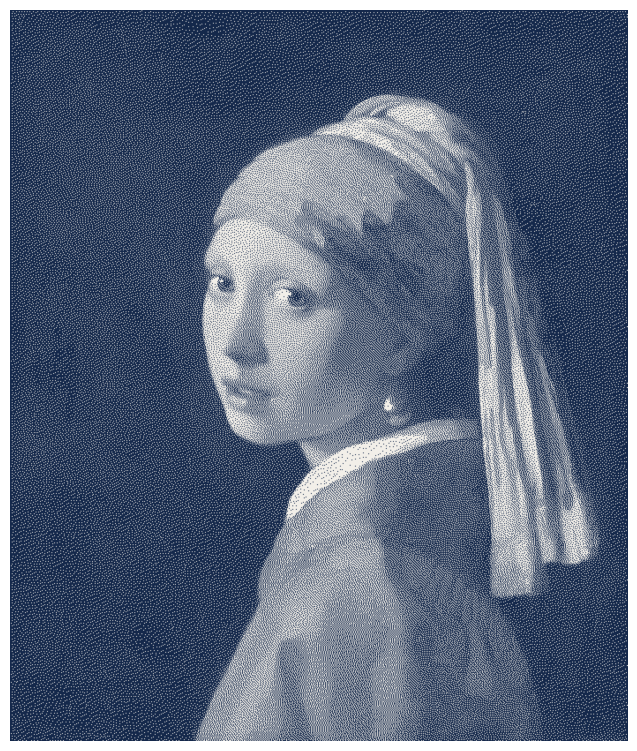

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch16_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(8, 9.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the dot that conquered the image

In 1879 the printer **Benjamin Henry Day Jr.** patented a cheap way to lay tone onto a printing plate: uniform fields of small dots <a class="cite" href="#ref-day1879">(Day 1879)</a>. **Ben-Day dots** became the workhorse of pulp comics, four colors of dot screens stacked into flesh and sky, and they would have stayed a printer's trade secret had **Roy Lichtenstein** not blown them up to canvas size. *Look Mickey* (1961) <a class="cite" href="#ref-nga">(National Gallery of Art, collection entry)</a> and *Whaam!* (1963) <a class="cite" href="#ref-tate">(Tate, collection entry)</a> reproduce, by hand and stencil, the mechanical texture of cheap printing, at a scale where the mechanism becomes the subject. It was a scandal precisely because everyone recognized the dots: the *reproduction process itself* had become the style.

Lichtenstein could count on that recognition because the mass-produced image had saturated the world for eighty years. Halftone screens, which turn a photograph into printable dots, carried pictures into newspapers from the 1880s on <a class="cite" href="#ref-mirseyedi2017">(Mirseyedi 2017)</a>, and in 1935 **Walter Benjamin** wrote the essay that still frames every discussion of the subject, *The Work of Art in the Age of Its Technological Reproducibility* <a class="cite" href="#ref-benjamin1936">(Benjamin 1935/36)</a>: what evaporates in mass reproduction, he argued, is the artwork's *aura*, its unique presence in one place and time, and what replaces it is a new, political way of seeing. One respectful paragraph is all we can give him here, but notice that today's session is spent entirely inside his subject: every technique below is a way of *re-encoding* an image for a reproduction technology, and every one of them has since been adopted as an aesthetic in its own right. The glitch artists made that adoption explicit: from the 2000s on, artists such as **Rosa Menkman** treat compression artifacts, scan lines and dither patterns not as failures but as the medium showing its true face <a class="cite" href="#ref-menkman2011">(Menkman 2011)</a>.

One more thread, running toward the sciences. In 1959 **David Hubel** and **Torsten Wiesel** discovered that neurons in the cat's primary visual cortex fire not at points of light but at *oriented edges*, each neuron tuned to its own angle <a class="cite" href="#ref-hubel1959">(Hubel and Wiesel 1959)</a> (a finding that earned them the 1981 Nobel Prize; <a class="cite" href="#ref-nobel1981">Nobel Foundation</a>). The mathematical filter that best mimics these neurons is the **Gabor filter**, a Gaussian window multiplied by a wave, and when researchers fit real cortical measurements <a class="cite" href="#ref-jones1987">(Jones and Palmer, 1987)</a>, Gabor functions matched remarkably well. So when we run a bank of Gabor filters over Hokusai later today, we are computing a crude sketch of what your own early visual system extracts from the print before you *see* anything at all. The gap between such computable features and felt aesthetic experience is an open research question, and it happens to be the one the instructor's field lives in.

## Convolution, finally opened

Chapter 13 used `convolve` to count a cell's neighbors; chapter 14 used it to diffuse chemicals. Time to open the box. **Convolution** (Faltung) slides a small grid of weights, the **kernel**, across the image; at every stop, each image value under the kernel is multiplied by the weight over it, and the products are summed into one output pixel.

One stop worked through by hand. Take a 5 x 5 image patch and the 3 x 3 *averaging* kernel (all weights $\tfrac{1}{9}$), centered on the middle pixel:

$$\text{image patch} = \begin{pmatrix} 0 & 0 & 0 & 9 & 9 \\ 0 & \mathbf{0} & \mathbf{0} & \mathbf{9} & 9 \\ 0 & \mathbf{0} & \mathbf{0} & \mathbf{9} & 9 \\ 0 & \mathbf{0} & \mathbf{0} & \mathbf{9} & 9 \\ 0 & 0 & 0 & 9 & 9 \end{pmatrix} \qquad \text{kernel} = \begin{pmatrix} 1/9 & 1/9 & 1/9 \\ 1/9 & 1/9 & 1/9 \\ 1/9 & 1/9 & 1/9 \end{pmatrix}$$

Centered on the middle pixel, the kernel covers the bold 3 x 3 window: six zeros and three nines. The output there is $\tfrac{1}{9}(0+0+9+0+0+9+0+0+9) = 3$: the hard 0-to-9 cliff has become a 3, a step on a ramp. Slide the kernel one pixel everywhere and every cliff softens: that is all a blur is. The whole operation is two loops and a multiply-sum, so we write it ourselves before ever trusting the library again:

In [2]:
# convolution by hand: slide the kernel, multiply, sum -- nothing else
import numpy as np
from scipy.ndimage import convolve

def convolve_manual(image, kernel):
    height, width = image.shape
    reach = kernel.shape[0] // 2
    out = np.zeros_like(image)
    for row in range(reach, height - reach):
        for col in range(reach, width - reach):
            window = image[row - reach:row + reach + 1,
                           col - reach:col + reach + 1]
            out[row, col] = np.sum(window * kernel)
    return out

rng = np.random.default_rng(13)
tiny = rng.random((40, 40))
blur_kernel = np.ones((3, 3)) / 9
ours = convolve_manual(tiny, blur_kernel)
scipys = convolve(tiny, blur_kernel)
# np.allclose: equal up to tiny floating-point rounding
print("matches scipy (away from the border):",
      np.allclose(ours[1:-1, 1:-1], scipys[1:-1, 1:-1]))

matches scipy (away from the border): True


(The borders differ because scipy invents values beyond the edge and we simply stop; every convolution implementation must choose some such policy. A second small print: textbooks define convolution with the kernel rotated 180 degrees first, and scipy's `convolve` duly rotates it; our slide-and-sum does not bother. For symmetric kernels nothing changes, and for the Sobel kernels below only the sign of the output flips, invisible in these autoscaled pictures.) From here we use scipy's `convolve` for speed, knowing exactly what it does.

Now the astonishing part. Blurring, sharpening and edge-finding are **the same operation with different weights**:

$$\text{blur} = \tfrac{1}{25}\begin{pmatrix} 1 & \cdots & 1 \\ \vdots & & \vdots \\ 1 & \cdots & 1 \end{pmatrix} \qquad \text{sharpen} = \begin{pmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{pmatrix} \qquad \text{Sobel}_x = \begin{pmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{pmatrix}$$

Read the Sobel kernel aloud: *right neighbors minus left neighbors*. Its output is large wherever brightness changes horizontally, an estimate of the derivative, which is why edge people call it a **gradient** filter. Its transpose (the same grid flipped so rows become columns) does the same vertically, and the length of the combined vector, $\sqrt{S_x^2 + S_y^2}$, measures edge strength regardless of direction (chapter 15's mosaic used exactly this, via `np.gradient`, to place its seeds).

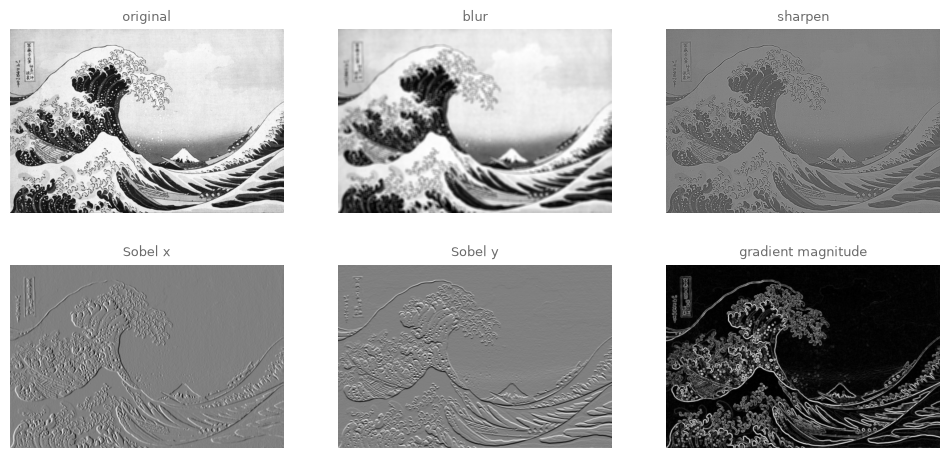

In [3]:
# one print, five filters: the same sliding sum, different nine numbers
from PIL import Image

original = Image.open("../assets/images/hokusai_wave.jpg")
scale_w = 480
scale_h = int(original.height * scale_w / original.width)
wave = np.asarray(original.convert("L").resize((scale_w, scale_h))) / 255

KERNELS = {
    "blur": np.ones((5, 5)) / 25,
    "sharpen": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    "Sobel x": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Sobel y": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
}
gradient = np.sqrt(convolve(wave, KERNELS["Sobel x"])**2
                   + convolve(wave, KERNELS["Sobel y"])**2)

fig, axes = plt.subplots(2, 3, figsize=(12, 5.6))
axes[0, 0].imshow(wave, cmap="gray")
axes[0, 0].set_title("original", fontsize=9, color="#6B6B6B")
for ax, (name, kernel) in zip(axes.flat[1:], KERNELS.items()):
    ax.imshow(convolve(wave, kernel), cmap="gray")
    ax.set_title(name, fontsize=9, color="#6B6B6B")
axes[1, 2].imshow(gradient, cmap="gray")
axes[1, 2].set_title("gradient magnitude", fontsize=9, color="#6B6B6B")
for ax in axes.flat:
    ax.axis("off")
plt.show()

The Sobel pair sees the wave differently: Sobel x lights up the falling walls of water (vertical edges change horizontally), Sobel y the horizontal rims of foam. The gradient magnitude combines them into a line drawing Hokusai never drew, yet every line of it is his.

**Try it.** Make the blur kernel 15 x 15 (`np.ones((15, 15)) / 225`) and the print goes properly myopic. Then try a kernel of your own invention; predicting what nine numbers will do before running them is exercise (a).

## The filter in your cortex

A **Gabor filter** is a **Gaussian** bump multiplied by a cosine wave. The Gaussian is the bell curve behind chapter 2's `rng.normal`, here met as a formula for the first time: the letter $e$ is a fixed number, roughly 2.718, and $e^{-t}$ falls smoothly toward 0 as $t$ grows, so the bell fades away from its center (chapter 24 will make this curve a whole chapter's brush). The product is: a little patch of *oriented stripes that fades out*. Formally, with coordinates rotated by the filter's angle $\theta$ (two more Greek dials inside: $\sigma$, sigma, sets the width of the bell, and $\lambda$, lambda, the spacing of the stripes):

$$G(x, y) = \underbrace{e^{-\frac{x'^2 + y'^2}{2\sigma^2}}}_{\text{Gaussian window}} \cdot \underbrace{\cos\!\left(\frac{2\pi x'}{\lambda}\right)}_{\text{wave}}$$

Convolved with an image, it responds strongly exactly where the image contains stripes of its own orientation and spacing, which is what Hubel and Wiesel's neurons do. First look the filter itself in the eye:

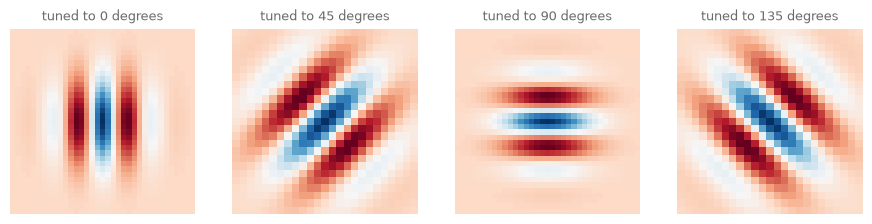

In [4]:
# the Gabor kernel itself: a Gaussian bump times a wave, at four angles
from skimage.filters import gabor_kernel, gabor

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, angle in zip(axes, [0, 45, 90, 135]):
    # gabor_kernel is complex (chapter 8's numbers); we keep the real part
    kernel = np.real(gabor_kernel(frequency=0.1, theta=np.deg2rad(angle)))
    ax.imshow(kernel, cmap="RdBu")
    ax.set_title(f"tuned to {angle} degrees", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

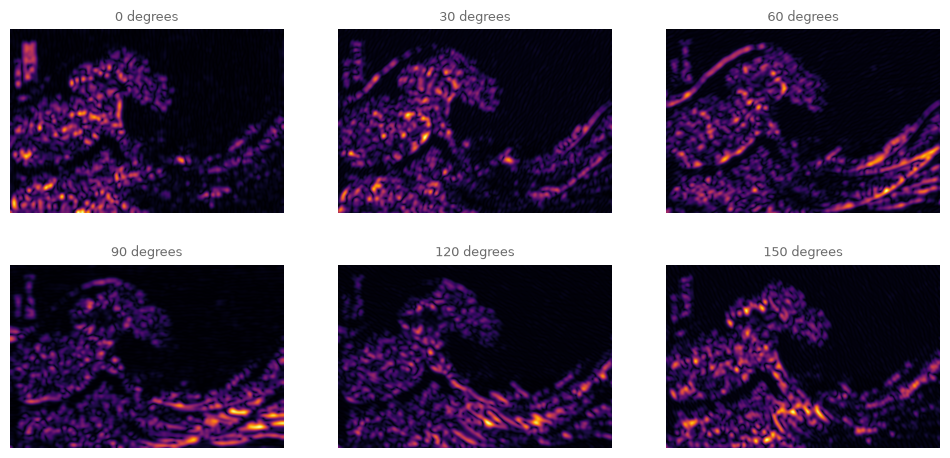

In [5]:
# a six-neuron cortex looks at the wave: what does each orientation see?
fig, axes = plt.subplots(2, 3, figsize=(12, 5.6))
for ax, angle in zip(axes.flat, [0, 30, 60, 90, 120, 150]):
    real, imag = gabor(wave, frequency=0.15, theta=np.deg2rad(angle))
    response = np.sqrt(real**2 + imag**2)
    ax.imshow(response, cmap="inferno")
    ax.set_title(f"{angle} degrees", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

Six pictures of the same print, none of which is the print: each panel is the firing map of one orientation channel, bright where that channel finds food. (One subtlety: skimage's angle names the direction the wave *travels*, so the 0-degree kernel is striped vertically and fires on *vertical* structure.) The wave's great claw feeds several channels at once as it curls through every orientation, while the flat sky feeds none, and the rain of foam flecks scatters energy everywhere. Vision science reads such maps as a first draft of seeing; for us they are also simply *pictures*, and "what does the painting look like to an orientation detector" is a legitimate answer to "show me this artwork again, differently."

**Try it.** In the cell above, change `frequency=0.15` to `0.05`: the channels go long-sighted and respond only to broad, slow stripes. Then edit the angle list itself; the six neurons are yours to rewire.

## Dithering: continuous tone from binary ink

Now the finale. Suppose your output device has exactly two states per pixel, ink or no ink (a 1970s terminal, a laser printer, a riso master). The naive move is a **threshold**: everything darker than 50 percent becomes ink. You will see in a moment how brutally that fails: entire tonal regions collapse into silhouette.

The fix, found by **Robert Floyd** and **Louis Steinberg** in 1976, is one of those algorithms that fits on an index card and changed everything <a class="cite" href="#ref-floyd1976">(Floyd and Steinberg 1976)</a>. Round each pixel to 0 or 1, but *keep the rounding error* and hand it to the neighbors not yet visited, in fixed shares of sixteenths:

$$\begin{matrix} & \bullet & 7/16 \\ 3/16 & 5/16 & 1/16 \end{matrix}$$

Watch it work on a single row of four pixels (0 is black ink, 1 is white paper), all mid-gray except the first, slightly brighter: 0.6, 0.5, 0.5, 0.5. Pixel one: 0.6 rounds *up* to 1 (paper), error $0.6 - 1 = -0.4$, of which $7/16$ (that is $-0.175$) flows right. Pixel two now holds $0.5 - 0.175 = 0.325$, rounds to 0 (ink), error $+0.325$, flows on. Pixel three holds $0.5 + 0.142 = 0.642$ ($7/16$ of $+0.325$ is the $+0.142$), rounds to 1. Pixel four, pushed down again, rounds to 0. Result: paper, ink, paper, ink, a 50 percent checker, which is exactly what mid-gray *should* look like in binary. No pixel is ever right; the neighborhood is right on average, because the error is never thrown away. **Error diffusion** (Fehlerdiffusion) is bookkeeping as art.

In [6]:
# Floyd-Steinberg: round each pixel, hand the rounding error onward
def floyd_steinberg(gray):
    canvas = gray.astype(float).copy()
    height, width = canvas.shape
    for row in range(height):
        for col in range(width):
            old = canvas[row, col]
            new = 1.0 if old > 0.5 else 0.0
            canvas[row, col] = new
            error = old - new
            if col + 1 < width:
                canvas[row, col + 1] += error * 7 / 16
            if row + 1 < height:
                if col > 0:
                    canvas[row + 1, col - 1] += error * 3 / 16
                canvas[row + 1, col] += error * 5 / 16
                if col + 1 < width:
                    canvas[row + 1, col + 1] += error * 1 / 16
    return canvas

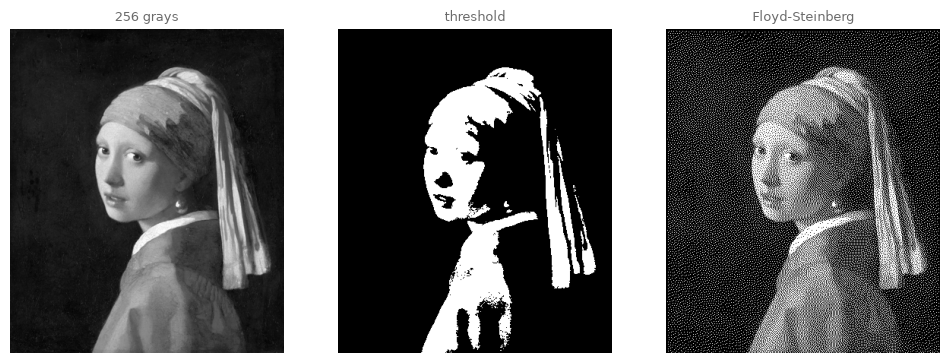

In [7]:
# the same Vermeer with one bit per pixel: threshold vs error diffusion
vermeer_image = Image.open("../assets/images/vermeer_pearl_earring.jpg")
v_w = 360
v_h = int(vermeer_image.height * v_w / vermeer_image.width)
vermeer = np.asarray(vermeer_image.convert("L").resize((v_w, v_h))) / 255

thresholded = (vermeer > 0.5).astype(float)
dithered = floyd_steinberg(vermeer)      # a few seconds of pure-python honesty

panels = [(vermeer, "256 grays"), (thresholded, "threshold"),
          (dithered, "Floyd-Steinberg")]
fig, axes = plt.subplots(1, 3, figsize=(12, 5.4))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

The threshold panel is a police sketch: face or no face. The Floyd-Steinberg panel, made of *exactly the same two values*, keeps the turban's sheen, the cheek's roundness, even the earring, carried entirely by dot spacing, like chapter 15's stipples but grown from arithmetic instead of geometry. Zoom in (the book page lets you) and the gray dissolves into checkers and worms; step back and the girl reassembles. The error-diffusion grain became a period texture in its own right: fax machines, dot-matrix printouts, 1-bit Macintosh art, and its revival is a staple of today's glitch and indie-game aesthetics.

**Try it.** In the Floyd-Steinberg cell, change `error * 7 / 16` to `error * 12 / 16` (and leave the rest): the bookkeeping now over-pays the right neighbor and the grain starts to smear into diagonal ropes. The exact sixteenths are not sacred; they are just unusually well chosen.

## Two colors are enough: duotone and halftone

Dressing the binary image is now easy: send ink pixels to one color and blank pixels to another. `np.where` (chapter 10) picks per pixel, and `np.kron` (chapter 13's pixel-art enlarger) scales the result up with hard edges so the dither grain survives as crisp pixels rather than blur.

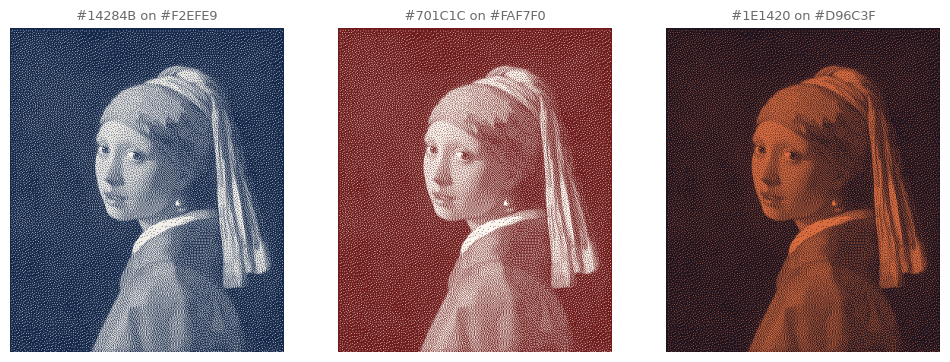

In [8]:
# duotone: the same 0/1 pixels wearing any two colors
import sys
sys.path.append("..")
from matplotlib.colors import to_rgb
from agap.helpers import save_artwork, show

def duotone(binary, dark="#14284B", light="#F2EFE9", upscale=3):
    # [..., None] adds a channel axis, so each 0/1 can meet an RGB triple
    colored = np.where(binary[..., None] > 0.5, to_rgb(light), to_rgb(dark))
    return np.kron(colored, np.ones((upscale, upscale, 1)))

inkings = [("#14284B", "#F2EFE9"), ("#701C1C", "#FAF7F0"),
           ("#1E1420", "#D96C3F")]
fig, axes = plt.subplots(1, 3, figsize=(12, 5.4))
for ax, (dark, light) in zip(axes, inkings):
    ax.imshow(duotone(dithered, dark, light, upscale=1))
    ax.set_title(f"{dark} on {light}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

And for the full Lichtenstein: **halftone**. Instead of diffusing error pixel by pixel, classic printing averages a whole cell of the image and prints *one dot whose size matches the cell's darkness*. We already know every ingredient: slice the image into cells, take each cell's mean, draw circles.

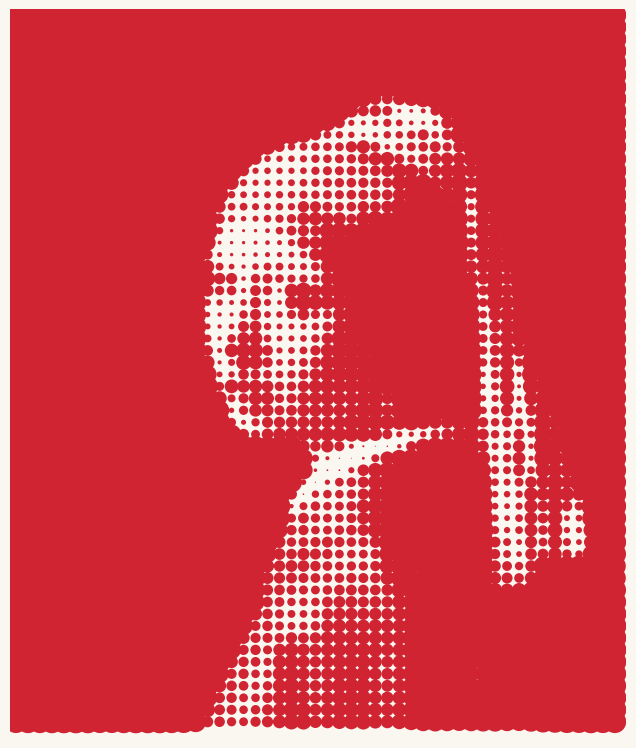

In [9]:
# halftone: one dot per cell, its width following the cell's mean darkness
from agap.helpers import PAPER

def halftone(gray, cell=8, dot_scale=1.0, ink="#1A1A1A", paper=PAPER,
             figsize=8):
    height, width = gray.shape
    xs, ys, sizes = [], [], []
    for row in range(0, height - cell + 1, cell):
        for col in range(0, width - cell + 1, cell):
            block = gray[row:row + cell, col:col + cell]
            darkness = 1 - block.mean()
            xs.append(col + cell / 2)
            ys.append(row + cell / 2)
            # the 2.6 converts cell units to scatter's point units
            sizes.append((darkness * cell * dot_scale * 2.6)**2)
    fig, ax = plt.subplots(figsize=(figsize, figsize * height / width))
    fig.patch.set_facecolor(paper)
    ax.set_facecolor(paper)
    ax.scatter(xs, ys, s=sizes, color=ink, linewidths=0)
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

art_benday = halftone(vermeer, cell=7, ink="#D02433")

**Look and compare.** Three renderings of tone with two inks each: Floyd-Steinberg's organic grain, the halftone's marching dots, the threshold's blunt silhouette. Which one says "machine" loudest? Most people answer the halftone, yet it is the *oldest* of the three, etched onto printing plates through photographic screens before electricity was common in homes <a class="cite" href="#ref-mirseyedi2017">(Mirseyedi 2017)</a>. And which would Lichtenstein have chosen? He *did* choose: the visible, regular, unapologetic dot. The grain of Floyd-Steinberg hides its algorithm; the halftone dot performs it.

## Export your artwork

Dither or halftone, any image, any two colors (chapter 6's extracted palettes are full of good pairs; try the darkest and lightest swatch of one painting applied to another). Replace `yourname` and run.

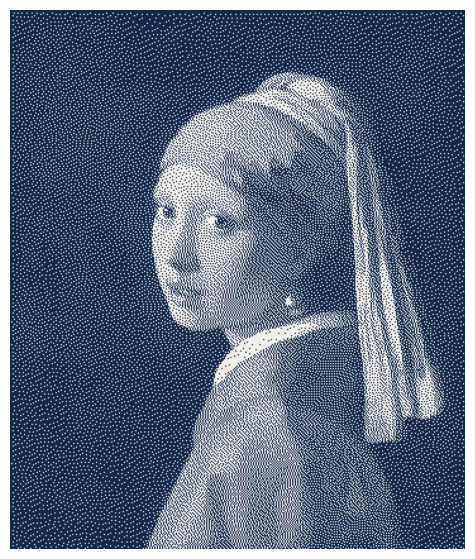

saved: assets/outputs/ch16_yourname.png


In [10]:
# save YOUR artwork: choose the technique and two colors, replace 'yourname'
my_artwork = duotone(dithered, "#14284B", "#F2EFE9", upscale=6)
show(my_artwork)
saved_path = save_artwork(my_artwork, "yourname", chapter=16)

## Exercises

**(a) Parameter exploration: nine numbers of your own.** Invent a 3 x 3 kernel, *write down your prediction* of what it will do to the wave, then run it. Suggested experiments: all zeros with a lone 2 somewhere off-center (where does the image go?); a kernel with weights summing to 0 (why does everything turn mid-gray except edges?); the sharpen kernel with its center raised to 9. The discipline of predicting before running is the whole exercise.

**(b) Code modification: ordered dithering.** Before error diffusion, printers used **Bayer matrices** <a class="cite" href="#ref-bayer1973">(Bryce Bayer, 1973)</a>: a fixed 4 x 4 pattern of thresholds, tiled across the image, each pixel compared against its own local threshold. No error is passed anywhere, so the texture is perfectly regular, crosshatch instead of grain. Implement it with the classic matrix and compare its texture to Floyd-Steinberg on the same Vermeer.

<details><summary>Solution</summary>

```python
bayer = np.array([[0, 8, 2, 10],
                  [12, 4, 14, 6],
                  [3, 11, 1, 9],
                  [15, 7, 13, 5]]) / 16 + 1 / 32   # thresholds spread over 0..1

tiled = np.tile(bayer, (v_h // 4 + 1, v_w // 4 + 1))[:v_h, :v_w]
ordered = (vermeer > tiled).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes[0].imshow(ordered, cmap="gray")
axes[0].set_title("ordered (Bayer)", fontsize=9, color="#6B6B6B")
axes[1].imshow(dithered, cmap="gray")
axes[1].set_title("Floyd-Steinberg", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()
```

`np.tile` repeats the little matrix like a wallpaper stamp (chapter 14 tiled its $f$ ramp the same way), and the whole dither is then a single comparison, no loop at all: that regularity is why ordered dithering was fast enough for early hardware, and its woven, textile-like texture (visible in the turban) is why pixel artists still choose it deliberately today.
</details>

**(c) Creative challenge: the pipeline.** Chain the chapters: take the Gabor response at your favorite orientation (or the gradient magnitude), threshold it into a mask of the wave's strongest strokes, and use the mask's dark pixels as the probability map for chapter 15's `sample_by_map`, then render stipples or a Voronoi mosaic seeded on pure orientation energy. You are now three transformations away from Hokusai and each one is defensible: generator, filter, renderer. Name the piece honestly (*Wave, 60 degrees, relaxed*) and bring it to the gallery.

## Further reading

- Walter Benjamin, "The Work of Art in the Age of Its Technological Reproducibility" (1935/36): the essay; short, dense, endlessly arguable.
- Margaret Livingstone, *Vision and Art: The Biology of Seeing* (2002): what Hubel and Wiesel's cortex does with paintings, written for artists by a neuroscientist from that very lab.
- Robert Ulichney, *Digital Halftoning* (MIT Press, 1987): the standard monograph on dithering, where the blue noise of chapter 15 reappears in printing.
- Rosa Menkman, *The Glitch Moment(um)* (Institute of Network Cultures, 2011), free PDF online: the manifesto of the aesthetics of error.

## References

- <span id="ref-bayer1973"></span>Bayer, B. E. (1973). An optimum method for two-level rendition of continuous-tone pictures. *Conference Record, IEEE 1973 International Conference on Communications*, pp. 26-11 to 26-15. Proves the optimality of the threshold matrix in exercise (b).
- <span id="ref-benjamin1936"></span>Benjamin, W. (1935/36). Das Kunstwerk im Zeitalter seiner technischen Reproduzierbarkeit. First published in French translation by P. Klossowski in *Zeitschrift für Sozialforschung*, 5 (1936); German text, Suhrkamp, 1963. The aura essay itself; short, dense, endlessly arguable.
- <span id="ref-day1879"></span>Day, B. (1879). Improvement in printing-films. U.S. Patent 214,493, granted 22 April 1879. [Google Patents](https://patents.google.com/patent/US214493A/en). The shading-medium patent behind the Ben-Day dot.
- <span id="ref-floyd1976"></span>Floyd, R. W., and Steinberg, L. (1976). An adaptive algorithm for spatial greyscale. *Proceedings of the Society for Information Display*, 17(2), 75–77. Three pages; the whole algorithm.
- <span id="ref-hubel1959"></span>Hubel, D. H., and Wiesel, T. N. (1959). Receptive fields of single neurones in the cat's striate cortex. *The Journal of Physiology*, 148(3), 574–591. [doi:10.1113/jphysiol.1959.sp006308](https://doi.org/10.1113/jphysiol.1959.sp006308). The discovery of the oriented-edge neurons.
- <span id="ref-jones1987"></span>Jones, J. P., and Palmer, L. A. (1987). An evaluation of the two-dimensional Gabor filter model of simple receptive fields in cat striate cortex. *Journal of Neurophysiology*, 58(6), 1233–1258. [doi:10.1152/jn.1987.58.6.1233](https://doi.org/10.1152/jn.1987.58.6.1233). The fit between Gabor functions and measured cortical fields.
- <span id="ref-menkman2011"></span>Menkman, R. (2011). *The Glitch Moment(um)*. Network Notebooks 04. Institute of Network Cultures. [Free PDF](https://networkcultures.org/blog/publication/no-04-the-glitch-momentum-rosa-menkman/). The theory of the aesthetics of error; chapter 17 returns to it.
- <span id="ref-mirseyedi2017"></span>Mirseyedi, S. (2017). Side by Side: The Halftone's Visual Culture of Pragmatism. *History of Photography*, 41(3), 286–310. [doi:10.1080/03087298.2017.1353208](https://doi.org/10.1080/03087298.2017.1353208). The photographic halftone screen and its arrival in the late nineteenth-century press.
- <span id="ref-nga"></span>National Gallery of Art, Washington. *Look Mickey*, Roy Lichtenstein, 1961. [Collection entry](https://www.nga.gov/artworks/71479-look-mickey).
- <span id="ref-nobel1981"></span>Nobel Foundation (1981). The Nobel Prize in Physiology or Medicine 1981. [nobelprize.org](https://www.nobelprize.org/prizes/medicine/1981/). Hubel and Wiesel's share, for discoveries concerning information processing in the visual system.
- <span id="ref-tate"></span>Tate, London. *Whaam!*, Roy Lichtenstein, 1963 (T00897). [Collection entry](https://www.tate.org.uk/art/artworks/lichtenstein-whaam-t00897).

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: half a million pixels, each politely handing its rounding error onward, in pure Python; give it a few seconds. Raise `big_w` at home for a poster-sized print. It runs automatically with *Restart & Run All*.

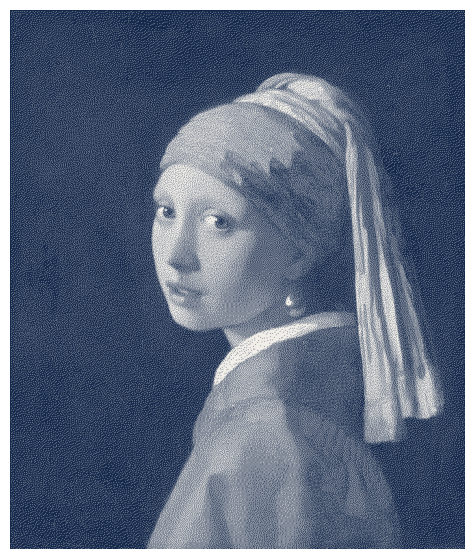

saved: assets/outputs/ch16_showpiece.png


In [11]:
# regenerate this chapter's showpiece: the dithered Vermeer, navy on cream
big_w = 700
big_h = int(vermeer_image.height * big_w / vermeer_image.width)
big = np.asarray(vermeer_image.convert("L").resize((big_w, big_h))) / 255
showpiece = duotone(floyd_steinberg(big), "#14284B", "#F2EFE9", upscale=3)
show(showpiece)
saved_path = save_artwork(showpiece, "showpiece", chapter=16)